## Code

  Abhishek V Ammanagi  |  2023BCSE07AED500
  Experiment 2: Fraud Detection – Feedforward NN
Fraud class weight: 27.57


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4982 - loss: 1.4068 - precision: 0.0480 - recall: 0.6720 - val_accuracy: 0.6100 - val_loss: 0.6369 - val_precision: 0.0456 - val_recall: 0.7333
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5856 - loss: 1.1471 - precision: 0.0703 - recall: 0.8400 - val_accuracy: 0.6600 - val_loss: 0.6070 - val_precision: 0.0605 - val_recall: 0.8667
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6403 - loss: 1.0594 - precision: 0.0764 - recall: 0.7920 - val_accuracy: 0.7083 - val_loss: 0.5522 - val_precision: 0.0699 - val_recall: 0.8667
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6912 - loss: 1.0059 - precision: 0.0911 - recall: 0.8240 - val_accuracy: 0.7617 - val_loss: 0.4959 - val_precision: 0.0844 - val_recall: 0.8667
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7429 - loss: 0.9731 - precision: 0.1012 - recall: 0.7600 - val_accuracy: 0.7800 - val_loss: 0.

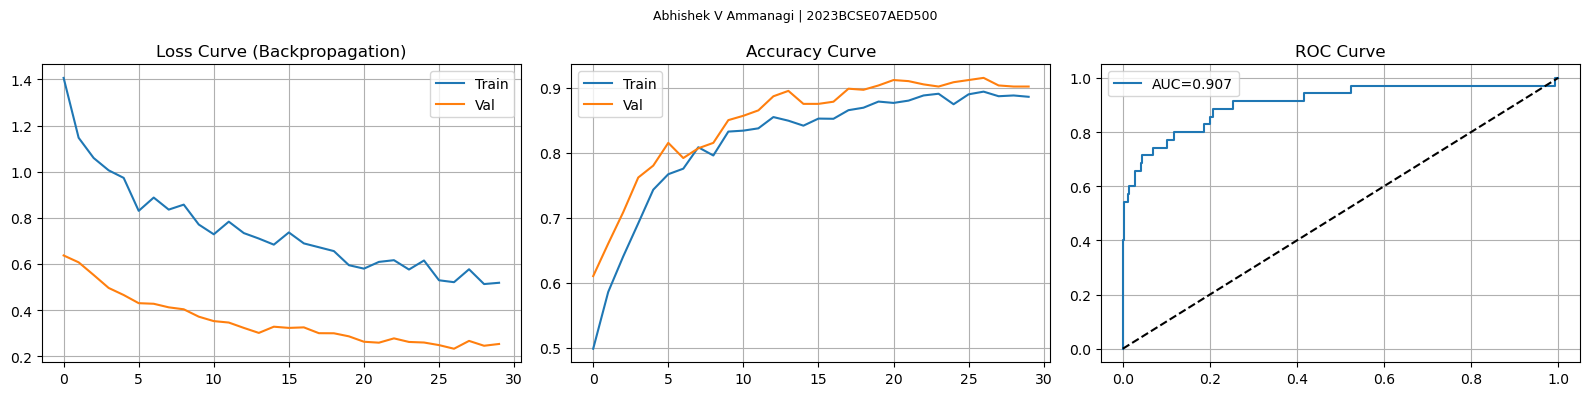

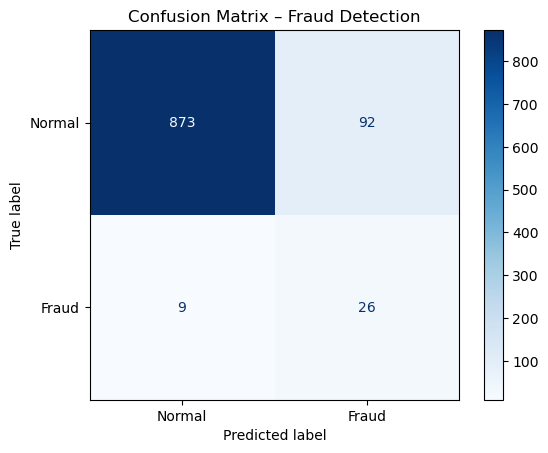

Abhishek V Ammanagi | 2023BCSE07AED500


: 

In [ ]:
# Experiment 2 – Fraud Detection Feedforward NN
# Abhishek V Ammanagi | 2023BCSE07AED500

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve)

print("=" * 55)
print("  Abhishek V Ammanagi  |  2023BCSE07AED500")
print("  Experiment 2: Fraud Detection – Feedforward NN")
print("=" * 55)

X, y = make_classification(n_samples=5000, n_features=20,
    n_informative=10, n_redundant=5,
    weights=[0.97, 0.03], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

neg, pos = np.bincount(y_train)
cw = {0: 1.0, 1: neg/pos}
print(f"Fraud class weight: {neg/pos:.2f}")

model = models.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
model.summary()

history = model.fit(X_train, y_train,
    validation_split=0.15, epochs=30,
    batch_size=32, class_weight=cw, verbose=1)

loss, acc, prec, rec = model.evaluate(X_test, y_test, verbose=0)
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)
auc    = roc_auc_score(y_test, y_prob)
f1     = 2 * prec * rec / (prec + rec + 1e-8)

print(f"\nAccuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print(classification_report(y_test, y_pred,
      target_names=['Normal','Fraud']))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(history.history['loss'],     label='Train')
ax[0].plot(history.history['val_loss'], label='Val')
ax[0].set_title('Loss Curve (Backpropagation)')
ax[0].legend(); ax[0].grid(True)
ax[1].plot(history.history['accuracy'],     label='Train')
ax[1].plot(history.history['val_accuracy'], label='Val')
ax[1].set_title('Accuracy Curve')
ax[1].legend(); ax[1].grid(True)
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[2].plot(fpr, tpr, label=f'AUC={auc:.3f}')
ax[2].plot([0,1],[0,1],'k--')
ax[2].set_title('ROC Curve')
ax[2].legend(); ax[2].grid(True)
plt.suptitle("Abhishek V Ammanagi | 2023BCSE07AED500", fontsize=9)
plt.tight_layout(); plt.savefig('exp2_fraud.png', dpi=300); plt.show()

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Fraud Detection")
plt.savefig('exp2_cm.png', dpi=300); plt.show()
print("Abhishek V Ammanagi | 2023BCSE07AED500")


## Result
_Run the cell above and paste your observations here._